In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# import sys
from dotenv import load_dotenv
load_dotenv()

DATA_SOURCE_PATH = os.getenv("DATA_SOURCE_PATH", "../data/raw/")

#Add the path for the processed (cleaned) data
DATA_PROCESSED_PATH = os.getenv("DATA_PROCESSED_PATH", "../data/processed/")    
CLEANED_DATA_FILENAME = os.getenv("CLEANED_DATA_FILENAME", "cleaned_house_data.csv")
SOURCE_PATH = os.getenv("SOURCE_PATH", "../src/")

# Add src to path for custom modules
# sys.path.append(SOURCE_PATH)

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("✅ Environment setup complete!")

✅ Environment setup complete!


In [4]:
# Load your cleaned house dataset
data_path = Path(DATA_PROCESSED_PATH)
df = pd.read_csv(data_path / CLEANED_DATA_FILENAME)

print(f"Dataset shape: {df.shape}")

#print head of the dataset
print("\n--- Dataset Head ---")
print(df.head)
print("\n---Summary statistic for numeric columns only")
print(df.describe())    


Dataset shape: (4602, 17)

--- Dataset Head ---
<bound method NDFrame.head of             date         price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0     2014-05-02  3.130000e+05       3.0       1.50         1340      7912   
1     2014-05-02  2.004950e+06       5.0       2.50         3650      9050   
2     2014-05-02  3.420000e+05       3.0       2.00         1930     11947   
3     2014-05-02  4.200000e+05       3.0       2.25         2000      8030   
4     2014-05-02  5.500000e+05       4.0       2.50         1940     10500   
...          ...           ...       ...        ...          ...       ...   
4597  2014-07-09  4.169042e+05       3.0       2.50         3010      7014   
4598  2014-07-10  2.034000e+05       4.0       2.00         2090      6630   
4599  2014-07-10  2.206000e+05       3.0       2.50         1490      8102   
4600  2014-07-10  6.700000e+05       3.0       2.50         1280      1438   
4601  2014-07-01  2.020000e+05       1.0       1.00          890


# Feature category (updated)

| Feature_Name | Feature_Type | Data_Type | Treatment_plan | Keep / Use |
|---|---|---:|---|---|
| date | Temporal | DateTime | Convert to `datetime`; use sale date to derive `house_age` and `renovation_age`. `sale_year` / `sale_month` were explored but **not retained** because the cleaned dataset covers too few months to capture meaningful seasonality. | Derived only |
| price | Target | Numeric | Keep as the raw target for final MAPE evaluation; create `log_price` for modeling. | Yes |
| bedrooms | Layout & Efficiency | Float / Integer-like | Keep; also use in density / spaciousness features. | Yes |
| bathrooms | Layout & Efficiency | Float | Keep; also use in density and interaction features. | Yes |
| sqft_living | Size & Structure | Integer | Keep as the **main overall size variable**. It is more interpretable than replacing it entirely with components. | Yes |
| sqft_lot | Size & Structure | Integer | Keep; apply `log1p` transform because lot size is skewed. | Yes |
| floors | Layout & Efficiency | Float | Keep as an original structural feature. | Yes |
| waterfront | Binary Categorical | Integer (0/1) | Keep; also interact with `log_sqft_living`. | Yes |
| view | Ordinal Categorical | Integer (0–4) | Keep as a quality / amenity signal. | Yes |
| condition | Ordinal Categorical | Integer (1–5) | Keep as a quality signal. | Yes |
| sqft_above | Size & Structure | Integer | Do **not** use in the final feature set because it overlaps strongly with `sqft_living`; handled indirectly through the decision to keep `sqft_living` as the main size feature. | No |
| sqft_basement | Size & Structure | Integer | Keep only through transformed / engineered versions such as `log_sqft_basement` and `basement_ratio`, instead of using it as a competing total-size feature. | Derived only |
| yr_built | Temporal | Integer (Year) | Transform into `house_age = sale_year - yr_built`. Construction year itself is less meaningful than age at sale. | Derived only |
| yr_renovated | Temporal | Integer (Year) | Convert into `renovated` and `renovation_age`; the raw year is not used directly. | Derived only |
| city | Location | String | Convert to leakage-safe out-of-fold target encoding: `city_price_index`. | Derived only |
| statezip | Location | String | Convert to leakage-safe out-of-fold target encoding: `statezip_price_index`. | Derived only |
| country | Location | String | Not useful because it is constant in this dataset. | No |
| street | High-cardinality location / identifier | String | Not used because it is too granular and likely noisy for this linear setup. | No |



# Feature engineering strategy summary (updated)

| Principle | Explanation |
|---|---|
| Main size representation | `sqft_living` was **retained** as the main overall size feature because it is the most interpretable measure of usable indoor area. |
| Multicollinearity handling | `sqft_above` was **not used in the final feature set** because it overlaps strongly with `sqft_living`. `sqft_basement` was kept only through transformed / ratio-based features (`log_sqft_basement`, `basement_ratio`) so that structural composition is preserved without creating a competing raw size measure. |
| Nonlinear transformations | `log_price`, `log_sqft_living`, `log_sqft_lot`, and `log_sqft_basement` were created because the raw variables were skewed and the log scale produced relationships that are more linear and more stable for regression. |
| Ratio features | `sqft_per_bedroom`, `bedrooms_per_sqft`, `bathrooms_per_sqft`, and `basement_ratio` capture layout efficiency, density, and structural composition beyond raw square footage alone. |
| Interaction terms | `bath_x_living` and `waterfront_x_living` allow the model to capture conditional effects, such as bathrooms mattering more in larger homes or waterfront premium increasing with size. |
| Temporal features | `house_age`, `renovated`, and `renovation_age` were retained; `sale_year`, `sale_month`, and `house_age_sq` were evaluated but not kept. |
| Location encoding | `city` and `statezip` were converted into leakage-safe out-of-fold target encodings (`city_price_index`, `statezip_price_index`) to capture geographic price levels. |
| Similarity-based feature | `knn_price` was added as a similarity-based feature using only training information, so the final model remains linear while benefiting from local comparable-house information. |


In [30]:
#after data cleasning
df_fe = df.copy()

# Target transformation
df_fe["log_price"] = np.log(df_fe["price"])


# 1. Temporal feature engineering (updated)

| Feature | Newly created | Data Type | Recommendation | Remark |
|---|---|---|---|---|
| `date` | No | DateTime | Convert to `datetime` immediately after loading. | Interpreted as the **sale / transaction date**, not build date. |
| `yr_built` | No | Integer (Year) | Transform into `house_age`. | Age at sale is more meaningful than raw construction year. |
| `yr_renovated` | No | Integer (Year) | Convert into `renovated` and `renovation_age`. | The raw renovation year is not directly modeled. |
| `house_age` | Yes: `date.dt.year - yr_built` | Numeric | Keep. | Captures depreciation / aging effects. Negative values should be checked. |
| `renovated` | Yes: `1 if yr_renovated > 0 else 0` | Binary | Keep. | Renovation status is often more informative than the raw year. |
| `renovation_age` | Yes: `sale_year - yr_renovated` if renovated else `0` | Numeric | Keep. | Measures how recent the renovation was. Negative values should be checked. |
| `sale_year` | Explored only | Integer | **Not retained**. | Limited year variation in the cleaned sample. |
| `sale_month` | Explored only | Integer | **Not retained**. | Too few distinct months to justify a seasonal feature. |
| `house_age_sq` | Explored only | Polynomial | **Not retained**. | Scatterplots did not show a strong enough nonlinear age pattern to justify keeping the squared term. |


In [31]:


# Feature Engineering

## Convert yr_built to age of the house
# House Age = sale year( Date) - year built (yr_built)
df_fe['date'] = pd.to_datetime(df_fe['date'], errors='coerce')  # Ensure 'date' is datetime
df_fe['house_age'] = df_fe['date'].dt.year - df_fe['yr_built']  

#check for negative values in house_age
negative_age_count = (df_fe['house_age'] < 0).sum()
print(f"Number of houses with negative age: {negative_age_count}")  

#print the head of the dataset with new column "house_age"
print("\n--- Dataset with House Age ---")       
print(df_fe.head()) 

##Renovation Feature
# Create a new column "renovated" to indicate if the house has been renovated as 1 else is 0
df_fe['renovated'] = np.where(df_fe['yr_renovated'] > 0, 1, 0)

##create renovation_age column where renovation age = sale year (date) - year renovated (yr_renovated).
# if not renovated, set renovation age to 0
df_fe['renovation_age'] = np.where(df_fe['renovated'] == 1, df_fe['date'].dt.year - df_fe['yr_renovated'], 0)   

# check for negative values in renovation_age
negative_renovation_age_count = (df_fe['renovation_age'] < 0).sum()
print(f"Number of houses with negative renovation age: {negative_renovation_age_count}")

# print the head of the dataset with new columns "renovated" and "renovation_age"
print("\n--- Dataset with Renovation Features ---")
print(df_fe.head())

#save the cleaned dataset to a new csv file
df_fe.to_csv('cleaned_house_dataset.csv', index=False)

print(df_fe.info())


Number of houses with negative age: 0

--- Dataset with House Age ---
           date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
3683 2014-06-30   544000.0       3.0       2.50         1460      1613   
4468 2014-06-06   315368.7       3.0       2.50         3080     12476   
2584 2014-06-16  1712500.0       3.0       3.25         2940      5432   
69   2014-05-04   365000.0       3.0       2.50         2200      7350   
1844 2014-06-04   275000.0       3.0       2.50         1720      8755   

      floors  waterfront  view  condition  ...  log_sqft_basement  \
3683     2.0           0     0          3  ...           5.638355   
4468     2.0           0     0          3  ...           0.000000   
2584     3.0           0     3          4  ...           6.216606   
69       1.0           0     0          5  ...           6.447306   
1844     1.0           0     0          3  ...           6.580639   

      sqft_per_bedroom  basement_ratio  bedrooms_per_sqft bathrooms_pe

<class 'pandas.core.frame.DataFrame'>
Index: 921 entries, 3683 to 1898
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  921 non-null    datetime64[ns]
 1   price                 921 non-null    float64       
 2   bedrooms              921 non-null    float64       
 3   bathrooms             921 non-null    float64       
 4   sqft_living           921 non-null    int64         
 5   sqft_lot              921 non-null    int64         
 6   floors                921 non-null    float64       
 7   waterfront            921 non-null    int64         
 8   view                  921 non-null    int64         
 9   condition             921 non-null    int64         
 10  sqft_above            921 non-null    int64         
 11  sqft_basement         921 non-null    int64         
 12  yr_built              921 non-null    int64         
 13  yr_renovated         

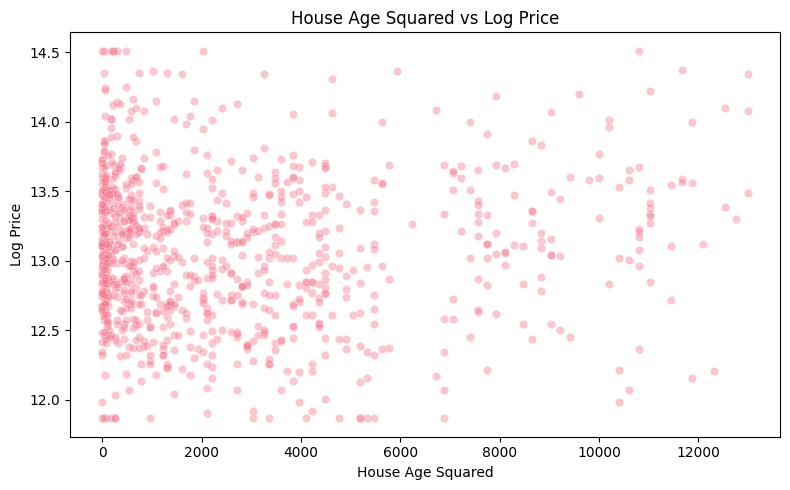

In [45]:
#create new feature house_age_squared by squaring the house_age column
df_fe['house_age_sq'] = df_fe['house_age'] ** 2
print(df_fe.info()) 

#plot the correlation between house_age_squared and the target variable log_price   
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_fe, x="house_age_sq", y="log_price", alpha=0.4)
plt.title("House Age Squared vs Log Price")
plt.xlabel("House Age Squared")
plt.ylabel("Log Price")
plt.tight_layout()
plt.show()


In [46]:
#remove the house_age_squared column as it does not seem to have a strong correlation with log_price
df_fe.drop(columns=['house_age_sq'], inplace=True)  

#print the info of the dataset after dropping the house_age_squared column
print(df_fe.info())

<class 'pandas.core.frame.DataFrame'>
Index: 921 entries, 3683 to 1898
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  921 non-null    datetime64[ns]
 1   price                 921 non-null    float64       
 2   bedrooms              921 non-null    float64       
 3   bathrooms             921 non-null    float64       
 4   sqft_living           921 non-null    int64         
 5   sqft_lot              921 non-null    int64         
 6   floors                921 non-null    float64       
 7   waterfront            921 non-null    int64         
 8   view                  921 non-null    int64         
 9   condition             921 non-null    int64         
 10  sqft_above            921 non-null    int64         
 11  sqft_basement         921 non-null    int64         
 12  yr_built              921 non-null    int64         
 13  yr_renovated         

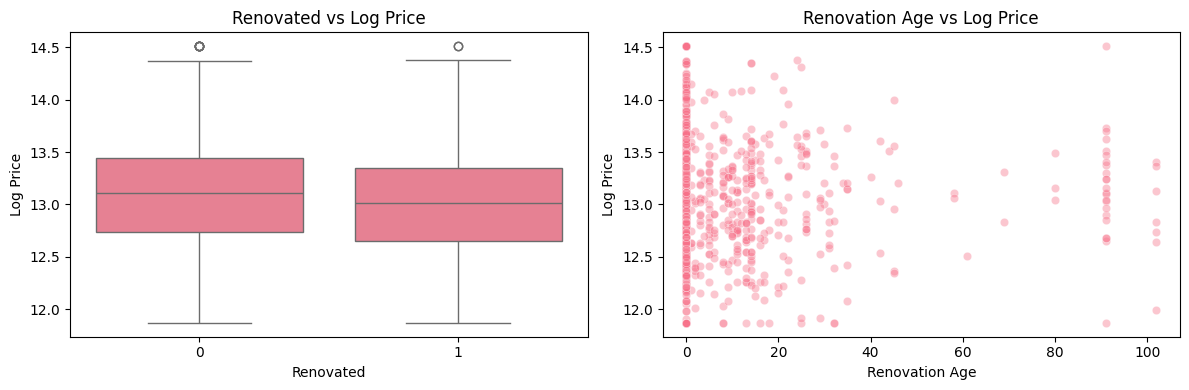

In [32]:
# Figure 1: Renovation Effects
# -----------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.boxplot(data=df_fe, x="renovated", y="log_price")
plt.title("Renovated vs Log Price")
plt.xlabel("Renovated")
plt.ylabel("Log Price")

plt.subplot(1,2,2)
sns.scatterplot(data=df_fe, x="renovation_age", y="log_price", alpha=0.4)
plt.title("Renovation Age vs Log Price")
plt.xlabel("Renovation Age")
plt.ylabel("Log Price")

plt.tight_layout()
plt.show()



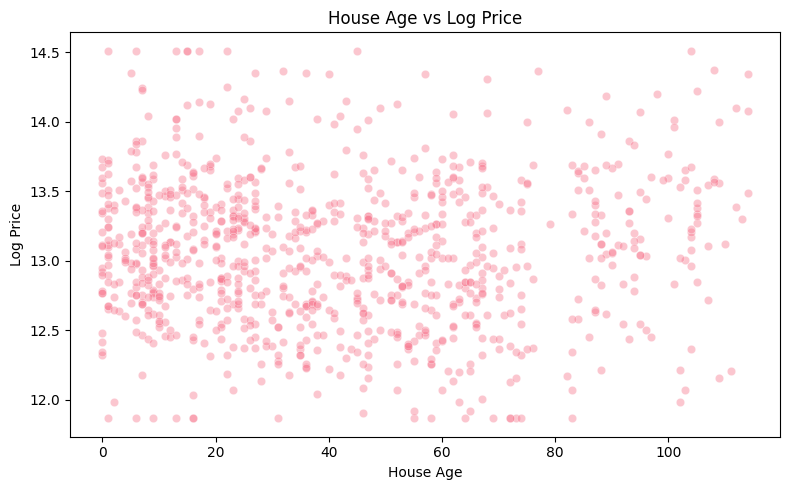

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_fe, x="house_age", y="log_price", alpha=0.4)
plt.title("House Age vs Log Price")
plt.xlabel("House Age")
plt.ylabel("Log Price")
plt.tight_layout()
plt.show()


# 2. Size & Structure Features



In [34]:
!pip install statsmodels

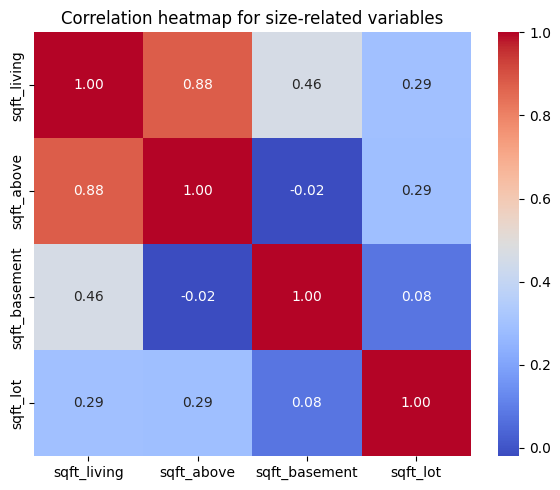

Summary of sqft_living - (sqft_above + sqft_basement):
count    921.000000
mean       0.325733
std        9.885336
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      300.000000
dtype: float64
Proportion exactly equal to 0: 0.998914223669924
         feature           VIF
0    sqft_living  58073.531733
1     sqft_above  43162.755893
2  sqft_basement   3248.677568
3       sqft_lot      1.293019


In [41]:
#Plot to understand the relationship between these features
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Correlation heatmap
size_cols = ["sqft_living", "sqft_above", "sqft_basement", "sqft_lot"]

plt.figure(figsize=(6, 5))
sns.heatmap(df_fe[size_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap for size-related variables")
plt.tight_layout()
plt.show()

# 2. Direct identity check
check_diff = df_fe["sqft_living"] - (
    df_fe["sqft_above"] + df_fe["sqft_basement"]
)

print("Summary of sqft_living - (sqft_above + sqft_basement):")
print(check_diff.describe())
print("Proportion exactly equal to 0:", (check_diff == 0).mean())

# 3. VIF
vif_cols = ["sqft_living", "sqft_above", "sqft_basement", "sqft_lot"]
X_vif = df_fe[vif_cols].dropna()

vif_table = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

print(vif_table.sort_values("VIF", ascending=False))

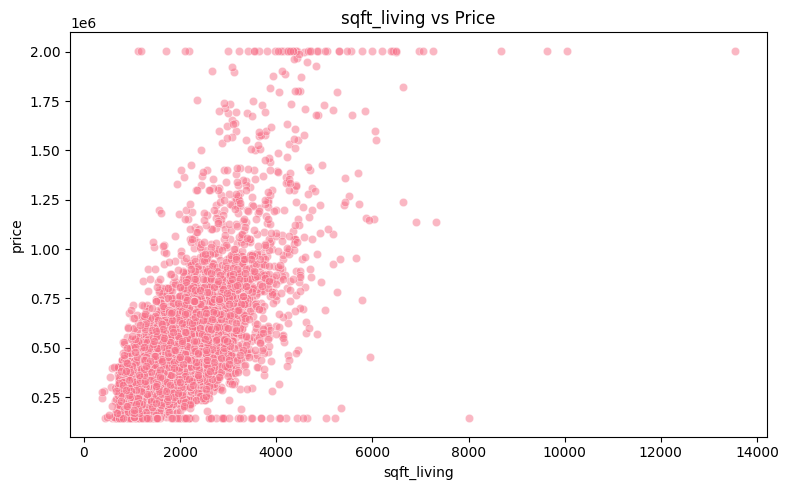

In [25]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_fe, x="sqft_living", y="price", alpha=0.5)
plt.title("sqft_living vs Price")
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.tight_layout()
plt.show()

| Feature | Newly created | Data Type | Recommendation | Reason |
|--------|-------| ------|---------------|-------|
| sqft_above | No | Numerical | Remove | Do **not** use in the final feature set because it overlaps strongly with `sqft_living`; handled indirectly through the decision to keep `sqft_living` as the main size feature.|
| sqft_basement | No | Numerical | Keep numeric | Represents basement area, which contributes to total house value but is usually priced lower than above-ground space. |
| sqft_lot | No | Numerical | Keep numeric | Represents lot space, which typically has higher market value than no lot |
| sqft_living | No| Numerical | keep|  Keep as the **main overall size variable**. It is more interpretable than replacing it entirely with components.|
| log_sqft_living | Log of sqft_living | Engineered | Apply log transformation | Living area influences price but with diminishing returns. Log transformation helps linear regression model the nonlinear relationship. |
| log_sqft_basement | Log of sqft_basement | Engineered | Apply log transformation | Basement area may have diminishing marginal value as size increases. Log transformation stabilizes variance. |
| log_sqft_lot | Log of sqft_lot | Engineered | Apply log transformation | lot area may have diminishing marginal value as size increases. Log transformation stabilizes variance. |
| basement_ratio | `sqft_basement / (sqft_living + sqft_basement)`| Engineered |  | Captures the proportion of basement space relative to total house area. Houses with large basements may have different valuation patterns. |

In [36]:
# Size transforms
# Keep sqft_living as the main size variable
# -------------------------
df_fe["log_sqft_living"] = np.log1p(df_fe["sqft_living"])
df_fe["log_sqft_lot"] = np.log1p(df_fe["sqft_lot"])
df_fe["log_sqft_basement"] = np.log1p(df_fe["sqft_basement"])

# Layout / spaciousness
df_fe["sqft_per_bedroom"] = df_fe["sqft_living"] / (df_fe["bedrooms"] + 1)

# Structural composition
df_fe["basement_ratio"] = df_fe["sqft_basement"] / (df_fe["sqft_living"] + 1)


print(df_fe.info())

<class 'pandas.core.frame.DataFrame'>
Index: 921 entries, 3683 to 1898
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  921 non-null    datetime64[ns]
 1   price                 921 non-null    float64       
 2   bedrooms              921 non-null    float64       
 3   bathrooms             921 non-null    float64       
 4   sqft_living           921 non-null    int64         
 5   sqft_lot              921 non-null    int64         
 6   floors                921 non-null    float64       
 7   waterfront            921 non-null    int64         
 8   view                  921 non-null    int64         
 9   condition             921 non-null    int64         
 10  sqft_above            921 non-null    int64         
 11  sqft_basement         921 non-null    int64         
 12  yr_built              921 non-null    int64         
 13  yr_renovated         

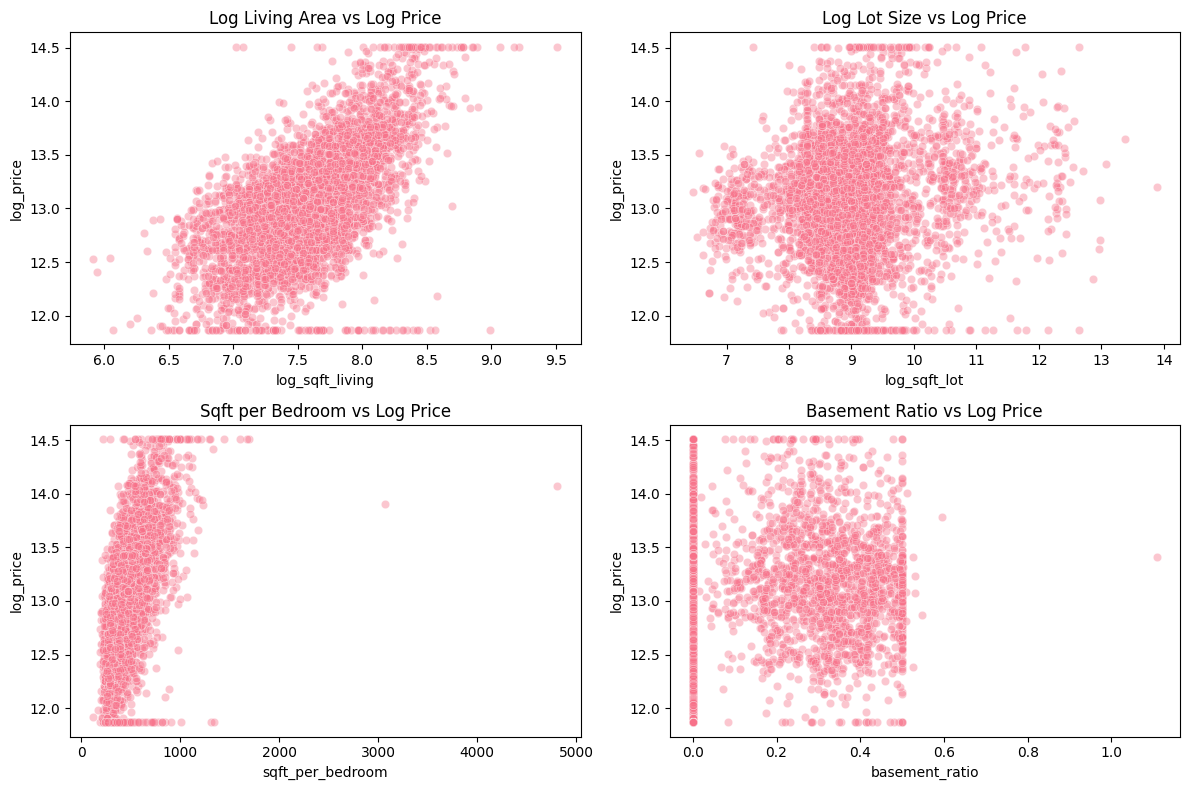

In [28]:
# Figure 2: Size & Layout Features
# -----------------------------
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.scatterplot(data=df_fe, x="log_sqft_living", y="log_price", alpha=0.4)
plt.title("Log Living Area vs Log Price")

plt.subplot(2,2,2)
sns.scatterplot(data=df_fe, x="log_sqft_lot", y="log_price", alpha=0.4)
plt.title("Log Lot Size vs Log Price")

plt.subplot(2,2,3)
sns.scatterplot(data=df_fe, x="sqft_per_bedroom", y="log_price", alpha=0.4)
plt.title("Sqft per Bedroom vs Log Price")

plt.subplot(2,2,4)
sns.scatterplot(data=df_fe, x="basement_ratio", y="log_price", alpha=0.4)
plt.title("Basement Ratio vs Log Price")

plt.tight_layout()
plt.show()

# 3. Layout & Efficiency & Interaction Term (New feature)

| Feature | Newly created | Type | Recommendation | Reason |
|--------|----- | ------|---------------|-------|
| bedrooms | No | Numerical | Keep numeric | Represents the number of sleeping spaces in the house and affects housing capacity. |
| bathrooms | No |  Numerical | Keep numeric | Bathrooms improve functionality and convenience, increasing property value. |
| floors | No|  Numerical | Keep numeric | Multi-floor houses may provide better space utilization and different price levels. |
| bedrooms_per_sqft | `bedrooms / (sqft_above + sqft_basement)`  | Engineered Ratio | `bedrooms / (sqft_above + sqft_basement)` | Captures housing density. Too many bedrooms relative to house size may indicate cramped layouts. |
| bathrooms_per_sqft | `bathrooms / (sqft_above + sqft_bathrooms)` | Engineered Ratio | `bathrooms / (sqft_above + sqft_bathrooms)` | Captures housing density. Too many bathrooms relative to house size may indicate cramped layouts. |
| bath_x_living |`bathrooms × log_sqft_living` | Interaction | `bathrooms × log_sqft_living` | The value of additional bathrooms depends on house size. Larger homes benefit more from additional bathrooms. |
| waterfront_x_living | `waterfront × log_sqft_living` |Interaction | `waterfront × log_sqft_living` | Waterfront premium increases with house size, particularly for luxury properties. |

In [37]:
# Density features
df_fe["bedrooms_per_sqft"] = df_fe["bedrooms"] / (df_fe["sqft_living"] + 1)
df_fe["bathrooms_per_sqft"] = df_fe["bathrooms"] / (df_fe["sqft_living"] + 1)

# Interaction features
df_fe["bath_x_living"] = df_fe["bathrooms"] * df_fe["log_sqft_living"]
df_fe["waterfront_x_living"] = df_fe["waterfront"] * df_fe["log_sqft_living"]


print(df_fe.info())

<class 'pandas.core.frame.DataFrame'>
Index: 921 entries, 3683 to 1898
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  921 non-null    datetime64[ns]
 1   price                 921 non-null    float64       
 2   bedrooms              921 non-null    float64       
 3   bathrooms             921 non-null    float64       
 4   sqft_living           921 non-null    int64         
 5   sqft_lot              921 non-null    int64         
 6   floors                921 non-null    float64       
 7   waterfront            921 non-null    int64         
 8   view                  921 non-null    int64         
 9   condition             921 non-null    int64         
 10  sqft_above            921 non-null    int64         
 11  sqft_basement         921 non-null    int64         
 12  yr_built              921 non-null    int64         
 13  yr_renovated         

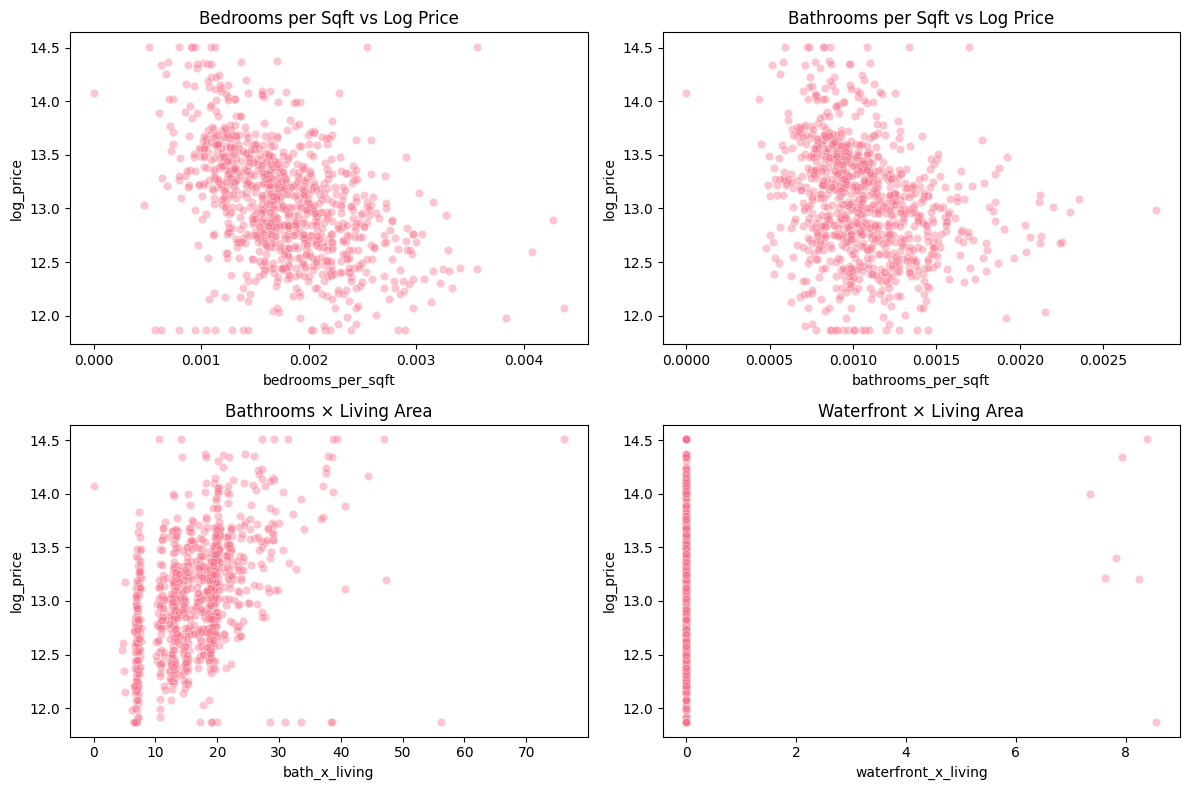

In [39]:
# -----------------------------
# plot Density & Interaction Features
# -----------------------------
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.scatterplot(data=df_fe, x="bedrooms_per_sqft", y="log_price", alpha=0.4)
plt.title("Bedrooms per Sqft vs Log Price")

plt.subplot(2,2,2)
sns.scatterplot(data=df_fe, x="bathrooms_per_sqft", y="log_price", alpha=0.4)
plt.title("Bathrooms per Sqft vs Log Price")

plt.subplot(2,2,3)
sns.scatterplot(data=df_fe, x="bath_x_living", y="log_price", alpha=0.4)
plt.title("Bathrooms × Living Area")

plt.subplot(2,2,4)
sns.scatterplot(data=df_fe, x="waterfront_x_living", y="log_price", alpha=0.4)
plt.title("Waterfront × Living Area")

plt.tight_layout()
plt.show()


# 4. Leakage-safe location and similarity features

| Engineered feature | Source columns | Method | Why it is used | Leakage handling |
|---|---|---|---|---|
| `city_price_index` | `city`, `price` | Out-of-fold target encoding | Captures average city-level price differences in numeric form. | Computed with **KFold on `train_df` only**; each validation fold receives means from the corresponding training folds. |
| `statezip_price_index` | `statezip`, `price` | Out-of-fold target encoding | Captures finer-grained neighborhood / ZIP-level price differences. | Computed with **KFold on `train_df` only** and then applied to `test_df` using mappings learned from the full training set. |
| `knn_price` | `sqft_living`, `house_age`, `bathrooms`, `price` | KNN-based meta-feature (`KNeighborsRegressor`) | Estimates the price of similar houses based on size, age, and bathrooms. This gives the linear model a local comparable-house signal. | Built out-of-fold on `train_df` and applied to `test_df` only after fitting KNN on the full training set. |

In [40]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.neighbors import KNeighborsRegressor

# 1. SPLIT FIRST (Crucial Step)
train_df, test_df = train_test_split(df_fe, test_size=0.2, random_state=42)
train_df = train_df.copy()
test_df = test_df.copy()

# Initialize columns
for df in [train_df, test_df]:
    df['city_price_index'] = np.nan
    df['statezip_price_index'] = np.nan
    df['knn_price'] = np.nan

# 2. K-FOLD ON TRAINING DATA ONLY
kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_mean = train_df['price'].mean()

for t_idx, v_idx in kf.split(train_df):
    # iloc is used because indices might not be 0 to N after split
    train_fold = train_df.iloc[t_idx]
    val_fold = train_df.iloc[v_idx]
    
    # Target Encoding (In-sample training)
    city_map = train_fold.groupby('city')['price'].mean()
    zip_map = train_fold.groupby('statezip')['price'].mean()
    
    train_df.iloc[v_idx, train_df.columns.get_loc('city_price_index')] = val_fold['city'].map(city_map)
    train_df.iloc[v_idx, train_df.columns.get_loc('statezip_price_index')] = val_fold['statezip'].map(zip_map)
    
    # KNN (In-sample training)
    knn = KNeighborsRegressor(n_neighbors=10)
    features = ['sqft_living', 'house_age', 'bathrooms']
    knn.fit(train_fold[features], train_fold['price'])
    train_df.iloc[v_idx, train_df.columns.get_loc('knn_price')] = knn.predict(val_fold[features])

# 3. APPLY TO TEST SET (Using full training knowledge)
# Encoding for Test
city_map_final = train_df.groupby('city')['price'].mean()
zip_map_final = train_df.groupby('statezip')['price'].mean()
test_df['city_price_index'] = test_df['city'].map(city_map_final)
test_df['statezip_price_index'] = test_df['statezip'].map(zip_map_final)

# KNN for Test
knn_final = KNeighborsRegressor(n_neighbors=10)
knn_final.fit(train_df[features], train_df['price'])
test_df['knn_price'] = knn_final.predict(test_df[features])

# Final Cleanup (Use train_mean to fill test NaNs to avoid leakage)
train_df.fillna(train_mean, inplace=True)
test_df.fillna(train_mean, inplace=True)

print(df_fe.info())

<class 'pandas.core.frame.DataFrame'>
Index: 921 entries, 3683 to 1898
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  921 non-null    datetime64[ns]
 1   price                 921 non-null    float64       
 2   bedrooms              921 non-null    float64       
 3   bathrooms             921 non-null    float64       
 4   sqft_living           921 non-null    int64         
 5   sqft_lot              921 non-null    int64         
 6   floors                921 non-null    float64       
 7   waterfront            921 non-null    int64         
 8   view                  921 non-null    int64         
 9   condition             921 non-null    int64         
 10  sqft_above            921 non-null    int64         
 11  sqft_basement         921 non-null    int64         
 12  yr_built              921 non-null    int64         
 13  yr_renovated         


# Final model feature set used for linear regression

| Feature | Role in model |
|---|---|
| `log_sqft_living` | Main transformed indoor size feature |
| `log_sqft_lot` | Transformed lot-size feature |
| `log_sqft_basement` | Transformed basement-size feature |
| `sqft_per_bedroom` | Spaciousness / layout efficiency |
| `basement_ratio` | Structural composition of living space |
| `bedrooms_per_sqft` | Bedroom density / crowding |
| `bathrooms_per_sqft` | Bathroom density / utility efficiency |
| `house_age` | Age at sale |
| `floors` | Structural layout feature |
| `view` | Amenity / quality feature |
| `condition` | Property quality feature |
| `renovated` | Renovation indicator |
| `renovation_age` | Recency of renovation |
| `bath_x_living` | Interaction: bathrooms × size |
| `waterfront_x_living` | Interaction: waterfront × size |
| `city_price_index` | City-level target encoding |
| `statezip_price_index` | ZIP-level target encoding |
| `knn_price` | Similar-house price meta-feature |
| `log_price` | Modeling target |
| `price` | Used only for final back-transformed evaluation (MAPE) |


In [ ]:
features = [
    "log_sqft_living",
    "log_sqft_lot",
    "log_sqft_basement",
    "sqft_per_bedroom",
    "basement_ratio",
    "bedrooms_per_sqft",
    "bathrooms_per_sqft",
    "house_age",
    "floors",
    "view",
    "condition",
    "renovated",
    "bath_x_living",
    "waterfront_x_living",
    "city_price_index",
    "statezip_price_index",
    "knn_price"
]

target = "log_price"

X_train = train_df[features].copy()
X_test = test_df[features].copy()

y_train_log = train_df[target].copy()
y_test_log = test_df[target].copy()     
y_train_actual = train_df["price"].copy()  # actual price for final MAPE
y_test_actual = test_df["price"].copy()   # actual price for final MAPE

In [ ]:
# Save features
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)

# Save targets
y_train_log.to_csv('../data/processed/y_train_log.csv', index=False)
y_test_log.to_csv('../data/processed/y_test_log.csv', index=False)
y_train_actual.to_csv('../data/processed/y_train_actual.csv', index=False)
y_test_actual.to_csv('../data/processed/y_test_actual.csv', index=False)